[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/generative-copolymer-workshop/blob/main/day2/05_mapping.ipynb)

# Day 2, async: mapping to the master dataset

Today's topics:
* Pooling per-view fingerprints into one vector per sequence, and what the spread tells you
* Placing a genuinely new sequence on the **persisted, deployed map**, never re-fitting it
* Fit-once, transform-forever: why the map notebooks 06-09 use is frozen the moment NB04 built it
* Who your latent neighbors are, and how notebook 06 gets its `(sequence, z)` training table

*Where are we in the pipeline?*

Notebook 04 built and validated a 2-D PCA map $g: \mathbb{R}^{1280} \to \mathbb{R}^2$, fit on 64 pre-simulated sequences and persisted to `data/master64/pca.joblib`.
Here you take a sequence that was not one of those 64, push it through the frozen $g$, and see where it lands relative to the rest of the design space.

*What's the goal today?*

Day 1 gave you a CNN feature vector for whatever sequence(s) you simulated.
Notebook 04 showed that compressing 1280-d fingerprints down to 2 PCA dimensions produces a map with real morphological structure, but it only demonstrated that on the 64 sequences the map was fit on.
A deployed map is only useful if it can also place sequences it has never seen.
Keep the original design problem in view while we do this bookkeeping.
Every point on this map is one polymer sequence's self-assembled structure, and it's this shared, deployed map that lets Day 3 search for a sequence that lands on a target morphology.

At length 10 the whole design space is small enough to enumerate exactly: $2^{10} = 1024$ binary strings.
Collapsing reversal-symmetric duplicates (a chain read head-to-tail is the same physical object as its reverse) leaves **528 canonical sequences**, every one already simulated and featurized in `data/exhaustive10/`.

That total isn't simply half of 1024.
32 of the 1024 strings are palindromes, reading the same forwards and backward, and a palindrome has no distinct reverse-partner to pair off with during the collapse, so it survives as its own canonical sequence.
496 reverse-pairs collapse to 496, plus 32 self-paired palindromes, giving $496 + 32 = 528$.

The deployed map, by contrast, was fit on a random subsample of 64 sequences, a deliberately small, deployment-honest choice.
A real cohort will only ever have a handful of freshly-simulated sequences to place, not the whole library.

So of the 528 canonical sequences, 464 are "new" relative to the fitted map, in exactly the sense a student's freshly-simulated sequence would be.
This notebook picks one of those 464, transforms it through the frozen PCA, and reads off where it lands: the deployment scenario in miniature.

This is a simplified, single-stage stand-in for the two-stage local-to-global embedding pipeline of Statt, Kleeblatt and Reinhart (*Soft Matter* 2021), who originally simulated only about 1,000-2,000 of their much larger design space (roughly 1.6-3%) with MD: the same "small fitted sample, big design space" situation, at a different chain length.

## Where this comes from

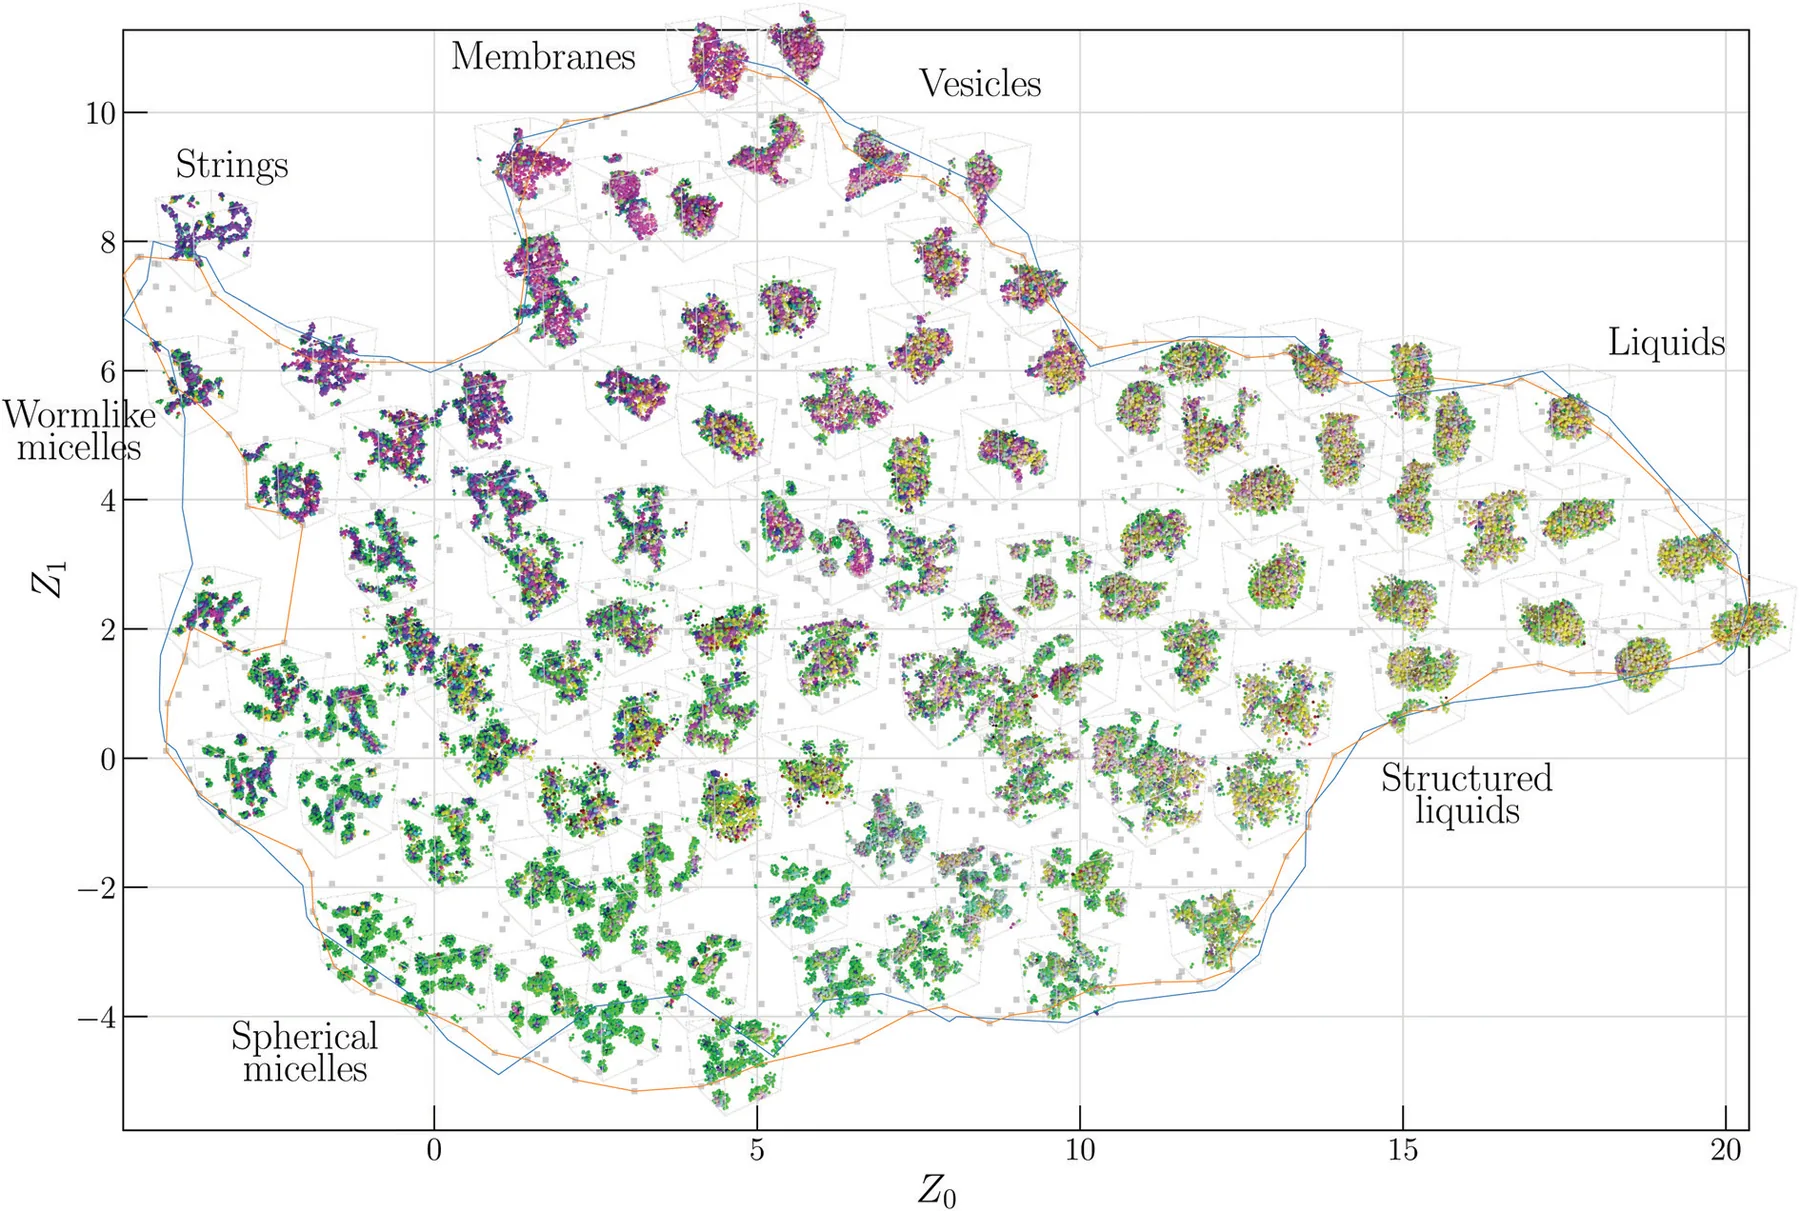

*Fig. 4, Statt, Kleeblatt and Reinhart, Soft Matter **17**, 7697 (2021). [doi.org/10.1039/d1sm01012c](https://doi.org/10.1039/d1sm01012c)*

This UMAP atlas organizes 1,022 self-assembled structures without morphology labels.
Strings, membranes, vesicles and liquids occupy distinct regions, with mixed structures between them.

Your frozen PCA map plays the same role, but it is not the same fitted object.
You place one unseen sequence, inspect its neighbors, and ask whether location still carries physical meaning.

The workshop uses a smaller sample and different features, so don't compare axes directly.
Compare the principle: a useful map makes nearby structures look alike.

This notebook is an outline of the session: the topics above and the published work it builds on.
The complete notebook, with its code and exercises, will be posted before the workshop begins on August 7.